# HW12 — Временные ряды: temporal split, baseline-модели и GRU-прогноз


## 2.3.1 Импорты, seed и среда


In [4]:
import random
import os
import json
import csv
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ── Seed ──────────────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_PATH      = 'S12-hw-dataset.csv'
ARTIFACTS_DIR  = 'artifacts'
FIGURES_DIR    = os.path.join(ARTIFACTS_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f'torch {torch.__version__} | pandas {pd.__version__} | numpy {np.__version__}')


Device: cuda
GPU: NVIDIA GeForce RTX 3060
torch 2.5.1+cu121 | pandas 2.3.3 | numpy 2.2.6


## 2.3.2 Данные и первичный анализ


In [5]:
# ── Загрузка ──────────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print('=== Sanity-check ===')
print(f'Наблюдений : {len(df):,}')
print(f'Диапазон дат: {df.date.min()} → {df.date.max()}')
print(f'Частота ряда: {pd.infer_freq(df.date)} (hourly)')
print(f'Колонки    : {df.columns.tolist()}')
print('\nПропуски:')
print(df.isnull().sum())
print('\nСтатистика target:')
print(df.target.describe().round(2))


=== Sanity-check ===
Наблюдений : 4,320
Диапазон дат: 2025-01-01 00:00:00 → 2025-06-29 23:00:00
Частота ряда: h (hourly)
Колонки    : ['date', 'target']

Пропуски:
date      0
target    0
dtype: int64

Статистика target:
count    4320.00
mean      135.61
std        21.38
min        69.10
25%       120.54
50%       135.84
75%       150.62
max       210.10
Name: target, dtype: float64


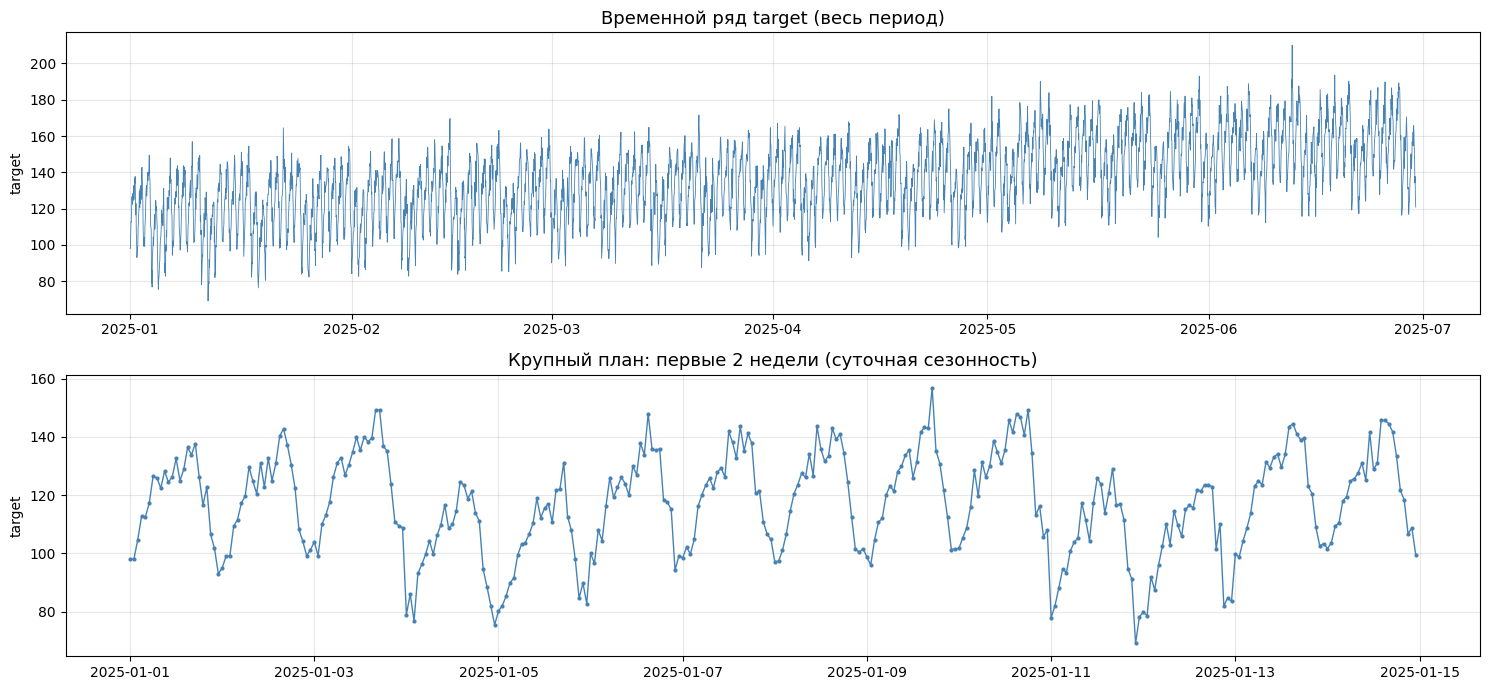


Комментарий:
- Ряд имеет выраженную суточную сезонность (период ~24 ч): значения выше днём, ниже ночью.
- Прослеживается слабый восходящий тренд на горизонте нескольких месяцев.
- Есть отдельные выбросы (пики ~210), возможно связанные с аномальными событиями.
- Пропусков нет — обработка не требуется.
- Ряд нестационарен из-за тренда и сезонности.



In [6]:
# ── Базовый график ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 7))

axes[0].plot(df.date, df.target, lw=0.6, color='steelblue')
axes[0].set_title('Временной ряд target (весь период)', fontsize=13)
axes[0].set_ylabel('target')
axes[0].grid(alpha=0.3)

# Крупный план — первые 2 недели
zoom = df[df.date < '2025-01-15']
axes[1].plot(zoom.date, zoom.target, lw=1.0, color='steelblue', marker='o', ms=2)
axes[1].set_title('Крупный план: первые 2 недели (суточная сезонность)', fontsize=13)
axes[1].set_ylabel('target')
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()
print("""
Комментарий:
- Ряд имеет выраженную суточную сезонность (период ~24 ч): значения выше днём, ниже ночью.
- Прослеживается слабый восходящий тренд на горизонте нескольких месяцев.
- Есть отдельные выбросы (пики ~210), возможно связанные с аномальными событиями.
- Пропусков нет — обработка не требуется.
- Ряд нестационарен из-за тренда и сезонности.
""")


## 2.3.3 Корректный temporal split


In [7]:
# ── Разбиение 70 / 15 / 15 по времени ────────────────────────────────────────
N       = len(df)
N_TRAIN = int(N * 0.70)   # 3024
N_VAL   = int(N * 0.15)   # 648
N_TEST  = N - N_TRAIN - N_VAL  # 648

train_df = df.iloc[:N_TRAIN].copy()
val_df   = df.iloc[N_TRAIN : N_TRAIN + N_VAL].copy()
test_df  = df.iloc[N_TRAIN + N_VAL :].copy()

VAL_START  = val_df.date.iloc[0]
TEST_START = test_df.date.iloc[0]

print('=== Границы split ===')
print(f'Train : {train_df.date.min().date()} → {train_df.date.max().date()}  ({len(train_df):,} ч)')
print(f'Val   : {val_df.date.min().date()} → {val_df.date.max().date()}    ({len(val_df):,} ч)')
print(f'Test  : {test_df.date.min().date()} → {test_df.date.max().date()}  ({len(test_df):,} ч)')

SPLIT_SUMMARY = (
    f"train={train_df.date.min().date()}/{train_df.date.max().date()} "
    f"val={val_df.date.min().date()}/{val_df.date.max().date()} "
    f"test={test_df.date.min().date()}/{test_df.date.max().date()}"
)

print("""
Почему random split здесь некорректен:
  Временной ряд — это упорядоченная последовательность. Каждое наблюдение
  зависит от предыдущих. При random split часть «будущих» точек попадает
  в обучающую выборку, а модель неявно «видит» будущее через лаговые признаки
  или саму структуру последовательности. Это ведёт к data leakage:
  метрики на validation окажутся оптимистически завышенными, а реальное
  качество прогноза на истинно новых данных будет значительно хуже.
""")


=== Границы split ===
Train : 2025-01-01 → 2025-05-06  (3,024 ч)
Val   : 2025-05-07 → 2025-06-02    (648 ч)
Test  : 2025-06-03 → 2025-06-29  (648 ч)

Почему random split здесь некорректен:
  Временной ряд — это упорядоченная последовательность. Каждое наблюдение
  зависит от предыдущих. При random split часть «будущих» точек попадает
  в обучающую выборку, а модель неявно «видит» будущее через лаговые признаки
  или саму структуру последовательности. Это ведёт к data leakage:
  метрики на validation окажутся оптимистически завышенными, а реальное
  качество прогноза на истинно новых данных будет значительно хуже.



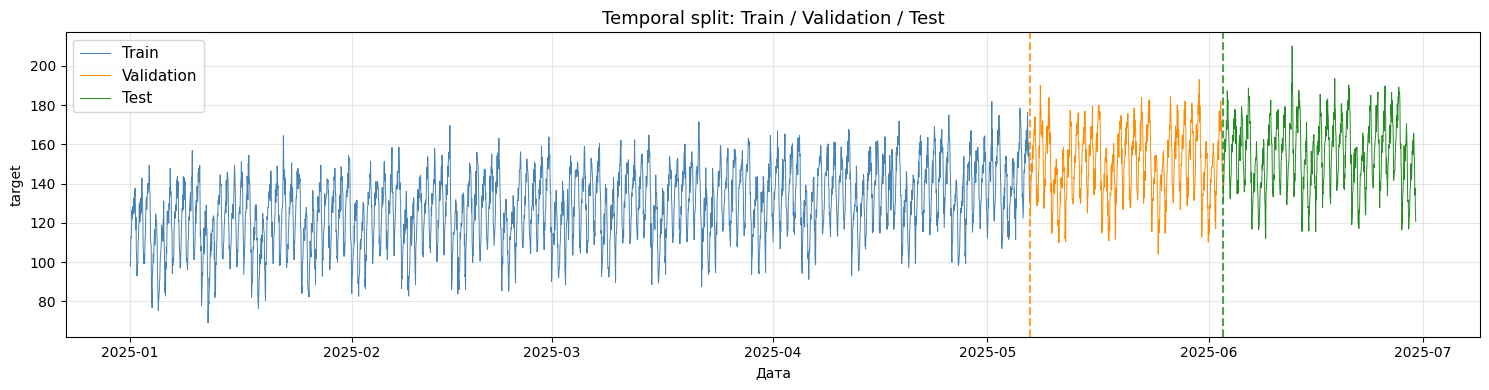

Сохранено: artifacts/figures/series_split.png


In [8]:
# ── Визуализация split ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(train_df.date, train_df.target, color='steelblue',   lw=0.7, label='Train')
ax.plot(val_df.date,   val_df.target,   color='darkorange',  lw=0.7, label='Validation')
ax.plot(test_df.date,  test_df.target,  color='forestgreen', lw=0.7, label='Test')
ax.axvline(VAL_START,  color='darkorange',  ls='--', lw=1.5, alpha=0.8)
ax.axvline(TEST_START, color='forestgreen', ls='--', lw=1.5, alpha=0.8)
ax.set_title('Temporal split: Train / Validation / Test', fontsize=13)
ax.set_xlabel('Дата'); ax.set_ylabel('target')
ax.legend(fontsize=11); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'series_split.png'), dpi=150)
plt.show()
print('Сохранено: artifacts/figures/series_split.png')


## 2.3.4 Признаки для baseline-моделей


In [9]:
def build_features(data: pd.DataFrame) -> pd.DataFrame:
    """Строим лаговые, rolling- и календарные признаки без утечки из будущего."""
    d = data.copy()
    # Лаги (сдвиг ≥ 1 — данные только из прошлого)
    d['lag_1']   = d['target'].shift(1)
    d['lag_7']   = d['target'].shift(7)
    d['lag_14']  = d['target'].shift(14)
    d['lag_24']  = d['target'].shift(24)   # сутки назад
    d['lag_168'] = d['target'].shift(168)  # неделя назад
    # Rolling (окно по уже сдвинутым значениям → нет утечки)
    shifted = d['target'].shift(1)
    d['rolling_mean_7']  = shifted.rolling(7).mean()
    d['rolling_std_7']   = shifted.rolling(7).std()
    d['rolling_mean_24'] = shifted.rolling(24).mean()
    d['rolling_std_24']  = shifted.rolling(24).std()
    # Календарные признаки
    d['hour']       = d['date'].dt.hour
    d['dayofweek']  = d['date'].dt.dayofweek   # 0=пн
    d['month']      = d['date'].dt.month
    d['is_weekend'] = (d['date'].dt.dayofweek >= 5).astype(int)
    return d

# Строим признаки на всём ряде (лаги используют историю всего ряда),
# затем нарезаем по split-индексам
full_feat = build_features(df)

FEAT_COLS = [
    'lag_1', 'lag_7', 'lag_14', 'lag_24', 'lag_168',
    'rolling_mean_7', 'rolling_std_7', 'rolling_mean_24', 'rolling_std_24',
    'hour', 'dayofweek', 'month', 'is_weekend'
]
TARGET_COL = 'target'

train_feat = full_feat.iloc[:N_TRAIN].dropna(subset=FEAT_COLS)
val_feat   = full_feat.iloc[N_TRAIN : N_TRAIN + N_VAL].dropna(subset=FEAT_COLS)
test_feat  = full_feat.iloc[N_TRAIN + N_VAL :].dropna(subset=FEAT_COLS)

X_train, y_train = train_feat[FEAT_COLS].values, train_feat[TARGET_COL].values
X_val,   y_val   = val_feat[FEAT_COLS].values,   val_feat[TARGET_COL].values
X_test,  y_test  = test_feat[FEAT_COLS].values,  test_feat[TARGET_COL].values

# Масштабирование — fit только на train!
scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_val_s   = scaler_X.transform(X_val)
X_test_s  = scaler_X.transform(X_test)

print(f'Признаков  : {len(FEAT_COLS)}')
print(f'Train rows : {len(X_train)}')
print(f'Val rows   : {len(X_val)}')
print(f'Test rows  : {len(X_test)}')
print()
print('Пояснение по утечкам:')
print('  Rolling и лаги строятся через .shift(1) — текущее значение target')
print('  недоступно при расчёте признаков. Масштабирование обучено только')
print('  на train-части, что исключает утечку статистики из val/test.')


Признаков  : 13
Train rows : 2856
Val rows   : 648
Test rows  : 648

Пояснение по утечкам:
  Rolling и лаги строятся через .shift(1) — текущее значение target
  недоступно при расчёте признаков. Масштабирование обучено только
  на train-части, что исключает утечку статистики из val/test.


## 2.3.5 Оконное представление для GRU


In [10]:
WINDOW_SIZE = 48   # 48 часов истории → предсказываем следующий час
HORIZON     = 1

# Масштабируем target (fit только на train)
scaler_y = StandardScaler()
train_vals = train_df['target'].values.reshape(-1, 1)
val_vals   = val_df['target'].values.reshape(-1, 1)
test_vals  = test_df['target'].values.reshape(-1, 1)

train_scaled = scaler_y.fit_transform(train_vals).flatten()
val_scaled   = scaler_y.transform(val_vals).flatten()
test_scaled  = scaler_y.transform(test_vals).flatten()

# Для непрерывности окно для val включает хвост train
val_context  = np.concatenate([train_scaled[-WINDOW_SIZE:], val_scaled])
test_context = np.concatenate([val_scaled[-WINDOW_SIZE:], test_scaled])

class TimeSeriesDataset(Dataset):
    def __init__(self, series: np.ndarray, window: int, horizon: int = 1):
        self.X, self.y = [], []
        for i in range(len(series) - window - horizon + 1):
            self.X.append(series[i : i + window])
            self.y.append(series[i + window + horizon - 1])
        self.X = torch.tensor(np.array(self.X), dtype=torch.float32).unsqueeze(-1)  # (N, W, 1)
        self.y = torch.tensor(np.array(self.y), dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 128

train_ds = TimeSeriesDataset(train_scaled,  WINDOW_SIZE)
val_ds   = TimeSeriesDataset(val_context,   WINDOW_SIZE)
test_ds  = TimeSeriesDataset(test_context,  WINDOW_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'window_size={WINDOW_SIZE}, horizon={HORIZON}, batch_size={BATCH_SIZE}')
print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}')
print(f'Пример формы: X={train_ds[0][0].shape}, y={train_ds[0][1].shape}')


window_size=48, horizon=1, batch_size=128
Train batches: 24, Val batches: 6, Test batches: 6
Пример формы: X=torch.Size([48, 1]), y=torch.Size([])


## 2.3.6 Вспомогательные функции: метрики и цикл обучения


In [11]:
def calc_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """MAE, RMSE, MAPE, sMAPE."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # MAPE: пропускаем нули в знаменателе
    mask = y_true != 0
    mape  = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    smape = np.mean(
        2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    ) * 100
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'sMAPE': smape}


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb).squeeze(-1)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(xb)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    preds, targets = [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb).squeeze(-1)
        total_loss += criterion(pred, yb).item() * len(xb)
        preds.append(pred.cpu().numpy())
        targets.append(yb.cpu().numpy())
    preds   = np.concatenate(preds)
    targets = np.concatenate(targets)
    return total_loss / len(loader.dataset), preds, targets


print('Функции calc_metrics, train_one_epoch, evaluate определены.')


Функции calc_metrics, train_one_epoch, evaluate определены.


## 3.1 B1 — Naive Last (наивный baseline)


In [12]:
# Прогноз = последнее известное значение (lag_1)
# На val: сдвигаем val_df на 1 шаг, первый элемент берём из конца train
val_target_arr   = val_df['target'].values
test_target_arr  = test_df['target'].values
train_target_arr = train_df['target'].values

b1_val_pred  = np.concatenate([[train_target_arr[-1]], val_target_arr[:-1]])
b1_test_pred = np.concatenate([[val_target_arr[-1]], test_target_arr[:-1]])

b1_val_metrics  = calc_metrics(val_target_arr,  b1_val_pred)
b1_test_metrics = calc_metrics(test_target_arr, b1_test_pred)

print('B1 Naive-Last — Validation:')
for k, v in b1_val_metrics.items(): print(f'  {k}: {v:.4f}')


B1 Naive-Last — Validation:
  MAE: 6.4448
  RMSE: 8.2010
  MAPE: 4.3979
  sMAPE: 4.3639


## 3.2 B2 — Moving Average baseline


In [13]:
MA_WINDOW = 24  # 24-часовое скользящее среднее

# Строим rolling mean на всём ряде (сдвиг 1, чтобы не было утечки)
rolling_pred = full_feat['lag_1'].rolling(MA_WINDOW).mean()

b2_val_pred  = rolling_pred.iloc[N_TRAIN : N_TRAIN + N_VAL].values
b2_test_pred = rolling_pred.iloc[N_TRAIN + N_VAL :].values

# Маскируем NaN (первые MA_WINDOW строк)
val_mask  = ~np.isnan(b2_val_pred)
test_mask = ~np.isnan(b2_test_pred)

b2_val_metrics  = calc_metrics(val_target_arr[val_mask],   b2_val_pred[val_mask])
b2_test_metrics = calc_metrics(test_target_arr[test_mask], b2_test_pred[test_mask])

print(f'B2 Moving-Average (window={MA_WINDOW}h) — Validation:')
for k, v in b2_val_metrics.items(): print(f'  {k}: {v:.4f}')


B2 Moving-Average (window=24h) — Validation:
  MAE: 13.3980
  RMSE: 16.1699
  MAPE: 9.1988
  sMAPE: 8.9950


## 3.3 B3 — Ridge на лаговых признаках


In [14]:
ridge = Ridge(alpha=1.0, random_state=SEED)
ridge.fit(X_train_s, y_train)

b3_val_pred  = ridge.predict(X_val_s)
b3_test_pred = ridge.predict(X_test_s)

b3_val_metrics  = calc_metrics(y_val,  b3_val_pred)
b3_test_metrics = calc_metrics(y_test, b3_test_pred)

print('B3 Ridge (lag + rolling + calendar features) — Validation:')
for k, v in b3_val_metrics.items(): print(f'  {k}: {v:.4f}')

# Топ признаков
coef_df = pd.DataFrame({'feature': FEAT_COLS, 'coef': ridge.coef_})
print('\nТоп-5 признаков по |коэф.|:')
print(coef_df.reindex(coef_df.coef.abs().sort_values(ascending=False).index).head())


B3 Ridge (lag + rolling + calendar features) — Validation:
  MAE: 5.0244
  RMSE: 6.3502
  MAPE: 3.3351
  sMAPE: 3.3842

Топ-5 признаков по |коэф.|:
       feature      coef
4      lag_168  6.709740
0        lag_1  6.614577
12  is_weekend -3.811675
11       month  2.399103
3       lag_24  2.251940


## 3.4 R1 — GRU Forecast


In [15]:
class GRUForecast(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x: (batch, window, features)
        out, _ = self.gru(x)      # out: (batch, window, hidden)
        last   = out[:, -1, :]    # берём только последний шаг
        return self.head(last)    # (batch, 1)


GRU_CONFIG = {
    'input_size'  : 1,
    'hidden_size' : 64,
    'num_layers'  : 2,
    'dropout'     : 0.2,
    'window_size' : WINDOW_SIZE,
    'batch_size'  : BATCH_SIZE,
    'lr'          : 1e-3,
    'epochs'      : 50,
    'seed'        : SEED,
    'scaler'      : 'StandardScaler (target only)'
}

model = GRUForecast(
    input_size=GRU_CONFIG['input_size'],
    hidden_size=GRU_CONFIG['hidden_size'],
    num_layers=GRU_CONFIG['num_layers'],
    dropout=GRU_CONFIG['dropout']
).to(DEVICE)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nПараметров: {total_params:,}')


GRUForecast(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

Параметров: 39,937


In [16]:
LR        = GRU_CONFIG['lr']
MAX_EPOCHS= GRU_CONFIG['epochs']
PATIENCE  = 7   # early stopping

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, verbose=False
)

best_val_loss   = float('inf')
best_epoch      = 0
patience_counter= 0
history = {'train_loss': [], 'val_loss': []}

BEST_MODEL_PATH = os.path.join(ARTIFACTS_DIR, 'best_gru.pt')

print(f'Обучение GRU — {MAX_EPOCHS} эпох, device={DEVICE}')
print('-' * 55)

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_preds_scaled, val_targets_scaled = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_epoch       = epoch
        patience_counter = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
    else:
        patience_counter += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{MAX_EPOCHS} | train_loss={train_loss:.5f} | val_loss={val_loss:.5f}'
              f'{" ← best" if patience_counter == 0 else ""}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping на эпохе {epoch} (лучшая: {best_epoch})')
        break

print(f'\nЛучшая эпоха: {best_epoch}, val_loss={best_val_loss:.5f}')
print(f'Модель сохранена → {BEST_MODEL_PATH}')

GRU_CONFIG['epochs_trained'] = best_epoch


Обучение GRU — 50 эпох, device=cuda
-------------------------------------------------------
Epoch   1/50 | train_loss=0.73857 | val_loss=0.65541 ← best
Epoch   5/50 | train_loss=0.15888 | val_loss=0.25125
Epoch  10/50 | train_loss=0.15601 | val_loss=0.25782

Early stopping на эпохе 10 (лучшая: 3)

Лучшая эпоха: 3, val_loss=0.18589
Модель сохранена → artifacts\best_gru.pt


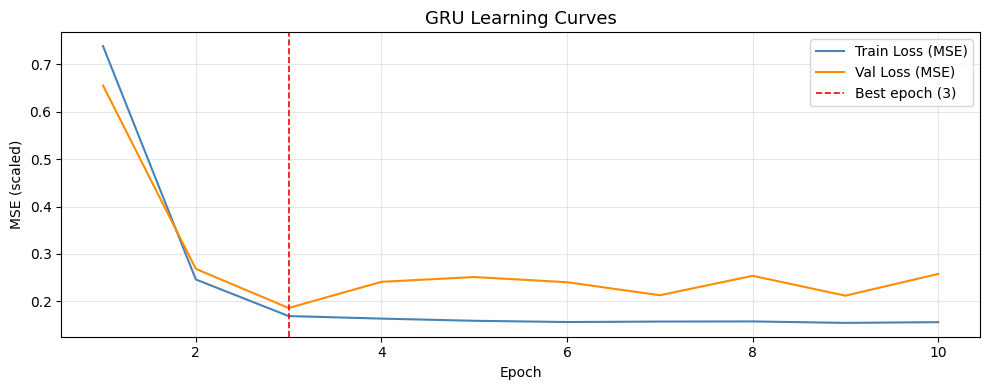

Сохранено: artifacts/figures/gru_learning_curves.png


In [17]:
# ── Кривые обучения ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
epochs_range = range(1, len(history['train_loss']) + 1)
ax.plot(epochs_range, history['train_loss'], label='Train Loss (MSE)', color='steelblue')
ax.plot(epochs_range, history['val_loss'],   label='Val Loss (MSE)',   color='darkorange')
ax.axvline(best_epoch, color='red', ls='--', lw=1.2, label=f'Best epoch ({best_epoch})')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (scaled)')
ax.set_title('GRU Learning Curves', fontsize=13)
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'gru_learning_curves.png'), dpi=150)
plt.show()
print('Сохранено: artifacts/figures/gru_learning_curves.png')


In [18]:
# ── Метрики GRU на val (в исходном масштабе) ──────────────────────────────────
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))

_, val_preds_s, val_tgts_s = evaluate(model, val_loader, criterion, DEVICE)
r1_val_pred = scaler_y.inverse_transform(val_preds_s.reshape(-1, 1)).flatten()
r1_val_true = scaler_y.inverse_transform(val_tgts_s.reshape(-1, 1)).flatten()

# test
_, test_preds_s, test_tgts_s = evaluate(model, test_loader, criterion, DEVICE)
r1_test_pred = scaler_y.inverse_transform(test_preds_s.reshape(-1, 1)).flatten()
r1_test_true = scaler_y.inverse_transform(test_tgts_s.reshape(-1, 1)).flatten()

r1_val_metrics  = calc_metrics(r1_val_true,  r1_val_pred)
r1_test_metrics = calc_metrics(r1_test_true, r1_test_pred)

print('R1 GRU — Validation:')
for k, v in r1_val_metrics.items(): print(f'  {k}: {v:.4f}')


R1 GRU — Validation:
  MAE: 6.3570
  RMSE: 7.9683
  MAPE: 4.2261
  sMAPE: 4.2801


## 4. Выбор лучшей модели и финальная оценка на test


In [19]:
# ── Сводка по val ─────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Model':    ['B1 naive-last', 'B2 moving-average', 'B3 ridge', 'R1 gru'],
    'Val MAE':  [b1_val_metrics['MAE'],  b2_val_metrics['MAE'],  b3_val_metrics['MAE'],  r1_val_metrics['MAE']],
    'Val RMSE': [b1_val_metrics['RMSE'], b2_val_metrics['RMSE'], b3_val_metrics['RMSE'], r1_val_metrics['RMSE']],
    'Val MAPE': [b1_val_metrics['MAPE'], b2_val_metrics['MAPE'], b3_val_metrics['MAPE'], r1_val_metrics['MAPE']],
})
print('=== Validation Results ===')
print(summary.to_string(index=False))

best_idx   = summary['Val MAE'].idxmin()
best_model = summary.loc[best_idx, 'Model']
print(f'\n>>> Лучшая модель по Val MAE: {best_model}')
print('>>> Тест проводим ОДИН РАЗ для неё:')

# Финальный test для лучшей модели
# (В зависимости от результата выбираем нужный массив)
test_metrics_map = {
    'B1 naive-last':    (b1_test_metrics, test_target_arr, b1_test_pred),
    'B2 moving-average':(b2_test_metrics, test_target_arr[test_mask], b2_test_pred[test_mask]),
    'B3 ridge':         (b3_test_metrics, y_test, b3_test_pred),
    'R1 gru':           (r1_test_metrics, r1_test_true, r1_test_pred),
}
final_test_metrics, final_test_true, final_test_pred = test_metrics_map[best_model]
print(f'Test MAE  = {final_test_metrics["MAE"]:.4f}')
print(f'Test RMSE = {final_test_metrics["RMSE"]:.4f}')
print(f'Test MAPE = {final_test_metrics["MAPE"]:.4f}%')


=== Validation Results ===
            Model   Val MAE  Val RMSE  Val MAPE
    B1 naive-last  6.444815  8.201023  4.397922
B2 moving-average 13.397980 16.169904  9.198834
         B3 ridge  5.024423  6.350156  3.335098
           R1 gru  6.357042  7.968302  4.226147

>>> Лучшая модель по Val MAE: B3 ridge
>>> Тест проводим ОДИН РАЗ для неё:
Test MAE  = 4.5637
Test RMSE = 5.8194
Test MAPE = 2.9254%


## 5. Визуализации


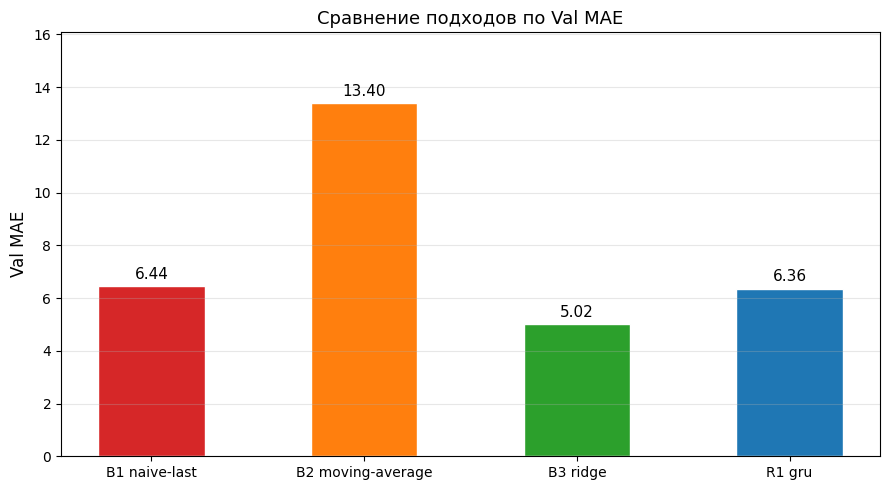

Сохранено: artifacts/figures/baselines_compare.png


In [20]:
# ── Сравнение моделей (baselines_compare) ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']
bars = ax.bar(summary['Model'], summary['Val MAE'], color=colors, edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=11)
ax.set_ylabel('Val MAE', fontsize=12)
ax.set_title('Сравнение подходов по Val MAE', fontsize=13)
ax.grid(axis='y', alpha=0.3); ax.set_ylim(0, max(summary['Val MAE']) * 1.2)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'baselines_compare.png'), dpi=150)
plt.show()
print('Сохранено: artifacts/figures/baselines_compare.png')


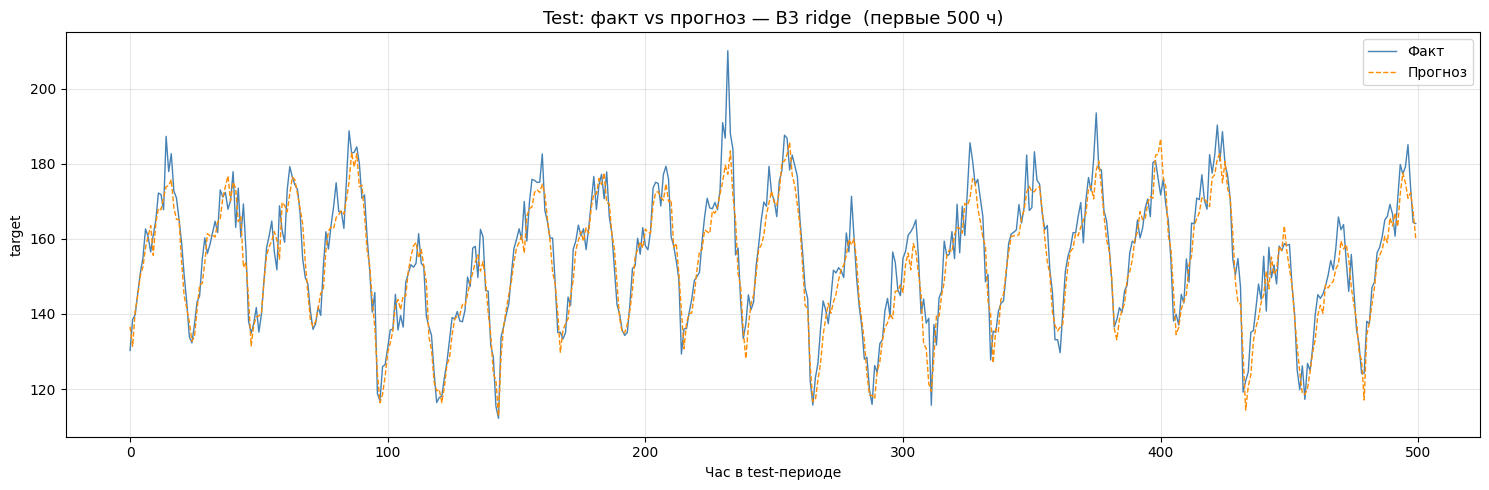

Сохранено: artifacts/figures/best_forecast_test.png


In [21]:
# ── Прогноз лучшей модели на test ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 5))

n_show = min(len(final_test_true), 500)   # показываем не более 500 точек
x_axis = range(n_show)

ax.plot(x_axis, final_test_true[:n_show],  lw=1.0, color='steelblue',   label='Факт')
ax.plot(x_axis, final_test_pred[:n_show],  lw=1.0, color='darkorange',  label='Прогноз', ls='--')
ax.set_title(f'Test: факт vs прогноз — {best_model}  (первые {n_show} ч)', fontsize=13)
ax.set_xlabel('Час в test-периоде'); ax.set_ylabel('target')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'best_forecast_test.png'), dpi=150)
plt.show()
print('Сохранено: artifacts/figures/best_forecast_test.png')


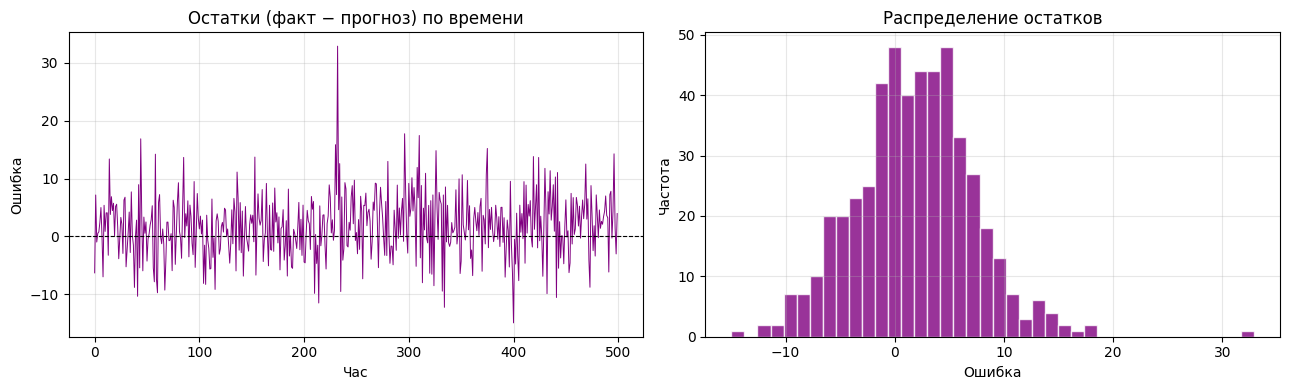

Сохранено: artifacts/figures/residuals_best.png


In [22]:
# ── Остатки ───────────────────────────────────────────────────────────────────
residuals = final_test_true[:n_show] - final_test_pred[:n_show]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(residuals, lw=0.7, color='purple')
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].set_title('Остатки (факт − прогноз) по времени')
axes[0].set_xlabel('Час'); axes[0].set_ylabel('Ошибка')
axes[0].grid(alpha=0.3)
axes[1].hist(residuals, bins=40, color='purple', edgecolor='white', alpha=0.8)
axes[1].set_title('Распределение остатков')
axes[1].set_xlabel('Ошибка'); axes[1].set_ylabel('Частота')
axes[1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'residuals_best.png'), dpi=150)
plt.show()
print('Сохранено: artifacts/figures/residuals_best.png')


## 6. Сохранение артефактов


In [23]:
# ── runs.csv ──────────────────────────────────────────────────────────────────
DATASET_NAME = 'S12-hw-dataset.csv'

def _m(d, k):   return round(d.get(k, float('nan')), 4)
def _mt(d, k):  return round(d.get(k, float('nan')), 4)

rows = [
    dict(
        experiment_id='B1', task='forecasting', dataset=DATASET_NAME, seed=SEED,
        split_summary=SPLIT_SUMMARY, window_size='', horizon=HORIZON,
        model_summary='naive-last (lag_1)',
        features_summary='lag_1', scaler='', optimizer='', lr='', epochs_trained='',
        best_val_mae=_m(b1_val_metrics,'MAE'), best_val_rmse=_m(b1_val_metrics,'RMSE'),
        best_val_mape=_m(b1_val_metrics,'MAPE'),
        test_mae=_mt(b1_test_metrics,'MAE'), test_rmse=_mt(b1_test_metrics,'RMSE'),
        test_mape=_mt(b1_test_metrics,'MAPE'), notes=''
    ),
    dict(
        experiment_id='B2', task='forecasting', dataset=DATASET_NAME, seed=SEED,
        split_summary=SPLIT_SUMMARY, window_size=MA_WINDOW, horizon=HORIZON,
        model_summary=f'moving-average (window={MA_WINDOW})',
        features_summary='rolling_mean_24', scaler='', optimizer='', lr='', epochs_trained='',
        best_val_mae=_m(b2_val_metrics,'MAE'), best_val_rmse=_m(b2_val_metrics,'RMSE'),
        best_val_mape=_m(b2_val_metrics,'MAPE'),
        test_mae=_mt(b2_test_metrics,'MAE'), test_rmse=_mt(b2_test_metrics,'RMSE'),
        test_mape=_mt(b2_test_metrics,'MAPE'), notes=''
    ),
    dict(
        experiment_id='B3', task='forecasting', dataset=DATASET_NAME, seed=SEED,
        split_summary=SPLIT_SUMMARY, window_size='', horizon=HORIZON,
        model_summary='Ridge(alpha=1.0)',
        features_summary=', '.join(FEAT_COLS), scaler='StandardScaler (X)',
        optimizer='', lr='', epochs_trained='',
        best_val_mae=_m(b3_val_metrics,'MAE'), best_val_rmse=_m(b3_val_metrics,'RMSE'),
        best_val_mape=_m(b3_val_metrics,'MAPE'),
        test_mae=_mt(b3_test_metrics,'MAE'), test_rmse=_mt(b3_test_metrics,'RMSE'),
        test_mape=_mt(b3_test_metrics,'MAPE'), notes=''
    ),
    dict(
        experiment_id='R1', task='forecasting', dataset=DATASET_NAME, seed=SEED,
        split_summary=SPLIT_SUMMARY, window_size=WINDOW_SIZE, horizon=HORIZON,
        model_summary=f'GRU(hidden={GRU_CONFIG["hidden_size"]}, layers={GRU_CONFIG["num_layers"]}, dropout={GRU_CONFIG["dropout"]})',
        features_summary='raw target sequence', scaler='StandardScaler (y)',
        optimizer='Adam', lr=LR, epochs_trained=GRU_CONFIG['epochs_trained'],
        best_val_mae=_m(r1_val_metrics,'MAE'), best_val_rmse=_m(r1_val_metrics,'RMSE'),
        best_val_mape=_m(r1_val_metrics,'MAPE'),
        test_mae=_mt(r1_test_metrics,'MAE'), test_rmse=_mt(r1_test_metrics,'RMSE'),
        test_mape=_mt(r1_test_metrics,'MAPE'), notes=f'early_stopping patience={PATIENCE}'
    ),
]

RUNS_PATH = os.path.join(ARTIFACTS_DIR, 'runs.csv')
with open(RUNS_PATH, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=rows[0].keys())
    writer.writeheader()
    writer.writerows(rows)

print(f'Сохранено: {RUNS_PATH}')
pd.read_csv(RUNS_PATH)


Сохранено: artifacts\runs.csv


,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset.csv,42,train=2025-01-01/2025-05-06 val=2025-05-07/202...,NaN,1,naive-last (lag_1),lag_1,NaN,NaN,NaN,NaN,6.4448,8.2010,4.3979,6.3424,8.0591,4.1485,NaN
1,B2,forecasting,S12-hw-dataset.csv,42,train=2025-01-01/2025-05-06 val=2025-05-07/202...,24.0,1,moving-average (window=24),rolling_mean_24,NaN,NaN,NaN,NaN,13.3980,16.1699,9.1988,13.1405,16.1108,8.7387,NaN
2,B3,forecasting,S12-hw-dataset.csv,42,train=2025-01-01/2025-05-06 val=2025-05-07/202...,NaN,1,Ridge(alpha=1.0),"lag_1, lag_7, lag_14, lag_24, lag_168, rolling...",StandardScaler (X),NaN,NaN,NaN,5.0244,6.3502,3.3351,4.5637,5.8194,2.9254,NaN
3,R1,forecasting,S12-hw-dataset.csv,42,train=2025-01-01/2025-05-06 val=2025-05-07/202...,48.0,1,"GRU(hidden=64, layers=2, dropout=0.2)",raw target sequence,StandardScaler (y),Adam,0.001,3.0,6.3570,7.9683,4.2261,6.9478,8.8340,4.4164,early_stopping patience=7


In [24]:
# ── best_gru_config.json ──────────────────────────────────────────────────────
CONFIG_PATH = os.path.join(ARTIFACTS_DIR, 'best_gru_config.json')
with open(CONFIG_PATH, 'w') as f:
    json.dump(GRU_CONFIG, f, indent=2)
print(f'Сохранено: {CONFIG_PATH}')
print(json.dumps(GRU_CONFIG, indent=2))


Сохранено: artifacts\best_gru_config.json
{
  "input_size": 1,
  "hidden_size": 64,
  "num_layers": 2,
  "dropout": 0.2,
  "window_size": 48,
  "batch_size": 128,
  "lr": 0.001,
  "epochs": 50,
  "seed": 42,
  "scaler": "StandardScaler (target only)",
  "epochs_trained": 3
}


In [25]:
# ── Итог ──────────────────────────────────────────────────────────────────────
print('=== Все артефакты ===')
for root, dirs, files in os.walk(ARTIFACTS_DIR):
    level = root.replace(ARTIFACTS_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    for file in files:
        print(f'{indent}  {file}')

print('\n=== Финальные метрики ===')
print(summary.to_string(index=False))
print(f'\nЛучшая модель: {best_model}')
print(f'Test MAE={final_test_metrics["MAE"]:.4f}  RMSE={final_test_metrics["RMSE"]:.4f}  MAPE={final_test_metrics["MAPE"]:.2f}%')


=== Все артефакты ===
artifacts/
  best_gru.pt
  best_gru_config.json
  runs.csv
  figures/
    baselines_compare.png
    best_forecast_test.png
    gru_learning_curves.png
    residuals_best.png
    series_split.png

=== Финальные метрики ===
            Model   Val MAE  Val RMSE  Val MAPE
    B1 naive-last  6.444815  8.201023  4.397922
B2 moving-average 13.397980 16.169904  9.198834
         B3 ridge  5.024423  6.350156  3.335098
           R1 gru  6.357042  7.968302  4.226147

Лучшая модель: B3 ridge
Test MAE=4.5637  RMSE=5.8194  MAPE=2.93%
